Unsupervized Learning

A discipline of learning that make no prediction but seek to learn from unlabelled data set.  They take input but provide no output.


Clustering

Grouping similar to each other in a group. A data analysis using in patterns recognition, image analysis, information retrieval.

k-means grouping of the whole data set into k groups of clustering of data set using it means value. assign the object into one of k-group to minimize the within-group sum of square value.

minimize $\color{orange}{\sum_{i=0}^n{\parallel x_i - \mu_{z_i}\parallel^2}} w.r.t (\mu,z) $

k-means is one of method using in clustering

Unsupervise learning 
To learn from unlabel dataset 

K-means is an unsupervise learning field that take the whole dataset 
and partition it into k number of cluster of the average value 
like-property togethers
K >= to 1 but K < number of data
The goal of K-means is to classify all data into one of the cluster
to minimize the within-cluster sum of squares value
cost function to minimize ∑ ₁ⁿ ‖Xᵢ - μᵥ‖² w.r.t (μ,v)
because it uses the distance calculation it similar to 
K-Nearest neighbors algorithm, where k-means k refer number of Cluster
where k in K-nn refer to number of data that nearest to point
this is also an iterative process that try to minimize the cost function

The K-means only take the input but provide no output as all unsupervise 
learning algorithm works
 comparison of the K algorithm
      K-NN                        K-means
    supervised                  unsupervised
    Classification              Clustering
    Labeled                     unlabeled
    K number near a point       number of Cluster 
    prediction                  no prediction
    
K-means is used for when accuracy is not require or data without label
use to take a quick peek into the data to some idea of how to handle them



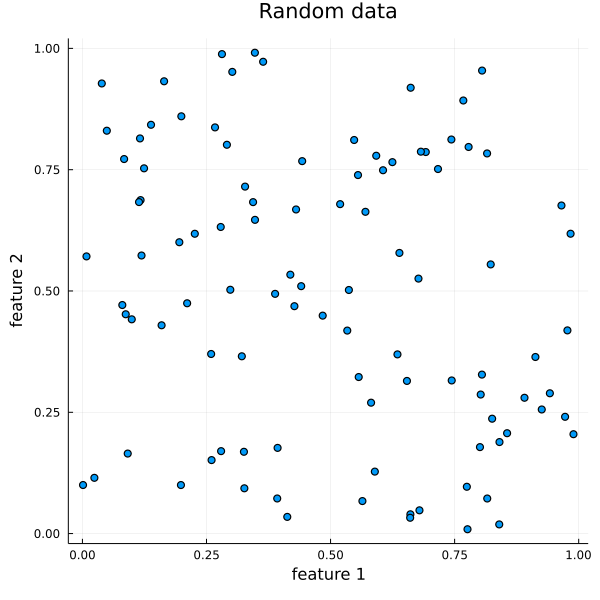

In [1]:

using Clustering, Plots, Random
gr(size = (600,600))

Random.seed!(1)
f1 = rand(100)
f2 = rand(100)
p_rand = scatter(f1, f2,
        xlabel = "feature 1", 
        ylabel = "feature 2",
        title = "Random data",
        legend = false)



to use k-means the input data must be in row(horizontal)
each row is the feature and each column is the sample data   

transpose into 2 row and 1 column

In [2]:

# transpose into 2 row and 1 column
X = [f1 f2]'
# cluster groups
k = 5


5


k-means is self iterate no need to write loop. It will stop when 
it found the solution, depend on data it may take too long, so 
it's good idea to set max loop to prevent infinite

In [3]:
iter = 100
Random.seed!(1)
results = kmeans(X,k;maxiter=iter,display=:iter)

# which cluster sample was assigned to
a = assignments(results)


  Iters               objv        objv-change | affected 
-------------------------------------------------------------
      0       5.133737e+00
      1       3.599105e+00      -1.534632e+00 |        5
      2       3.401434e+00      -1.976702e-01 |        5
      3       3.302680e+00      -9.875429e-02 |        4
      4       3.122812e+00      -1.798677e-01 |        4
      5       3.078729e+00      -4.408363e-02 |        2
      6       3.068276e+00      -1.045275e-02 |        2
      7       3.050735e+00      -1.754069e-02 |        3
      8       3.014258e+00      -3.647777e-02 |        2
      9       2.985014e+00      -2.924349e-02 |        0
     10       2.985014e+00       0.000000e+00 |        0
K-means converged with 10 iterations (objv = 2.9850140325642447)


100-element Vector{Int64}:
 4
 4
 3
 3
 2
 2
 3
 1
 1
 1
 4
 4
 3
 ⋮
 5
 1
 5
 5
 2
 4
 1
 4
 1
 2
 4
 2

In [4]:
c = counts(results)
# center of the cluster
μ = results.centers



2×5 Matrix{Float64}:
 0.81064   0.707789  0.21796   0.219972  0.519351
 0.187188  0.764085  0.241722  0.773834  0.447067

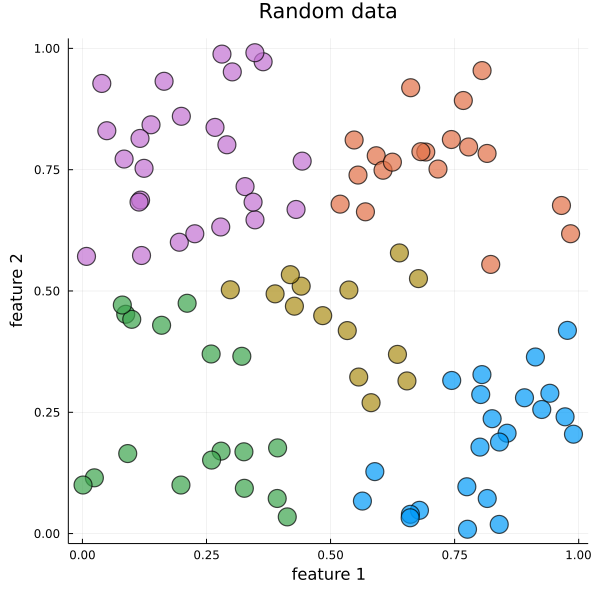

In [5]:
p_kmeans = scatter(f1, f2,
        xlabel = "feature 1", 
        ylabel = "feature 2",
        title = "Random data",
        legend = false,
        group = a,
        markersize=10,
        alpha =0.7)



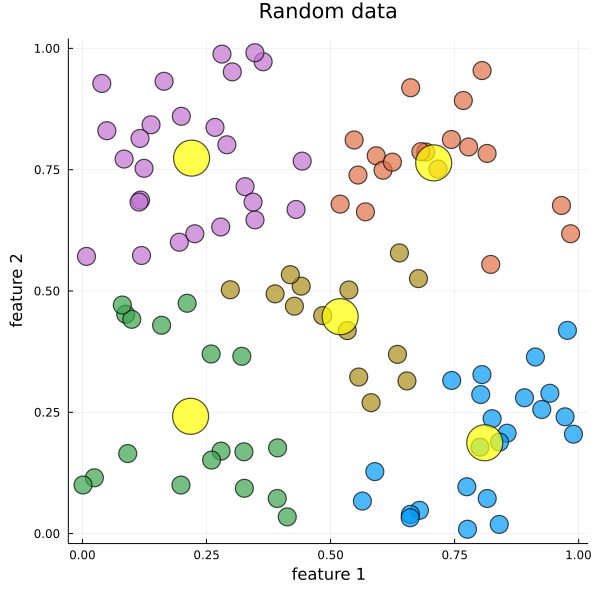

In [6]:
# show centers cluser group
p_center = scatter!(μ[1,:], μ[2,:],
        color=:yellow,
        markersize=20,
        alpha =0.7,
        legend = false)



In [7]:
savefig(p_kmeans,"plotKmeans.svg")


# Application of kmeans 


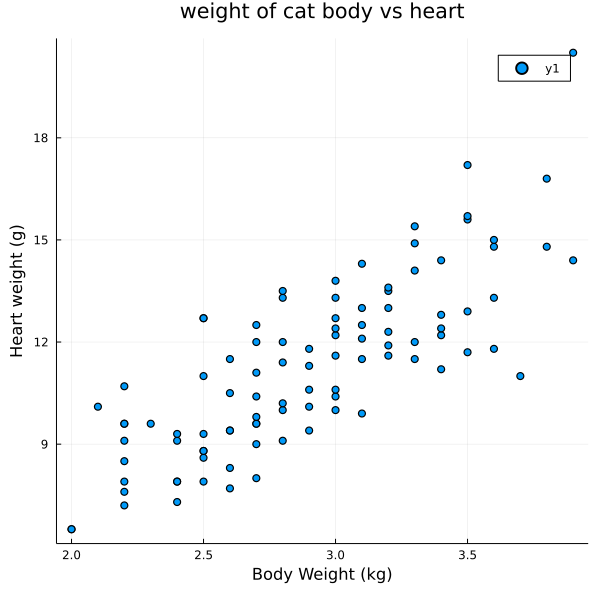

In [8]:
using RDatasets
cats = dataset("boot","catsM")
#vscodedisplay(cats)

p_cats = scatter(cats.BWt,cats.HWt,
xlabel = "Body Weight (kg)",
ylabel = "Heart weight (g)",
title = "weight of cat body vs heart",
legend= true)


 normalization (scale feature)
 since the data are in difference format
 both axes are in difference scale 
 must nomalize them to the same scale

In [9]:
f1 = cats.BWt 
f2 = cats.HWt 
f1_min= minimum(f1)
f2_min= minimum(f2)

f1_max= maximum(f1)
f2_max= maximum(f2)

f1_norm = (f1 .- f1_min) ./ (f1_max .- f1_min)
f2_norm = (f2 .- f2_min) ./ (f2_max .- f2_min)
X = [f1_norm f2_norm]'



2×97 adjoint(::Matrix{Float64}) with eltype Float64:
 0.0  0.0  0.0526316  0.105263  …  0.947368  0.947368  1.0       1.0
 0.0  0.0  0.257143   0.05         0.592857  0.735714  0.564286  1.0

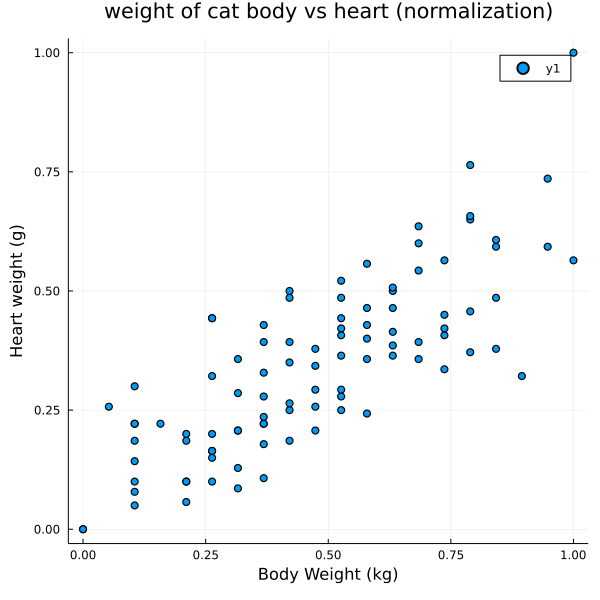

In [10]:
p_cats = scatter(f1_norm,f2_norm,
xlabel = "Body Weight (kg)",
ylabel = "Heart weight (g)",
title = "weight of cat body vs heart (normalization)",
legend= true)




In [11]:
k = 3
iter = 5



5

In [12]:
Random.seed!(1)


TaskLocalRNG()

In [13]:
result = kmeans(X,k;maxiter=iter,display=:iter)

  Iters               objv        objv-change | affected 
-------------------------------------------------------------
      0       4.051395e+00
      1       2.761346e+00      -1.290049e+00 |        3
      2       2.245173e+00      -5.161724e-01 |        3
      3       2.190548e+00      -5.462522e-02 |        3
      4       2.175210e+00      -1.533814e-02 |        0
      5       2.175210e+00       0.000000e+00 |        0
K-means converged with 5 iterations (objv = 2.175210079512196)


KmeansResult{Matrix{Float64}, Float64, Int64}([0.2299168975069252 0.5290858725761773 0.8145363408521304; 0.1870300751879699 0.38176691729323303 0.5619047619047619], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  3, 3, 3, 3, 3, 3, 3, 3, 3, 3], [0.08784202878402762, 0.08784202878402762, 0.03634588637021707, 0.034315796305323915, 0.02730183282519502, 0.023112788786526922, 0.017489802750007055, 0.015540286101242293, 0.01672181134291792, 0.01672181134291792  …  0.04158618664455638, 0.034371156588212326, 0.006565034139232706, 0.0017180953637225826, 0.0028065307378719595, 0.06426091858719474, 0.018602411417013798, 0.04785411209728618, 0.03440243779875729, 0.22632420650624052], [38, 38, 21], [38, 38, 21], 2.175210079512196, 5, true)

In [14]:
a = assignments(result)


97-element Vector{Int64}:
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 ⋮
 3
 3
 3
 3
 3
 3
 3
 3
 3
 3
 3
 3

In [15]:
c = counts(result)



3-element Vector{Int64}:
 38
 38
 21

In [16]:
μ = result.centers

2×3 Matrix{Float64}:
 0.229917  0.529086  0.814536
 0.18703   0.381767  0.561905

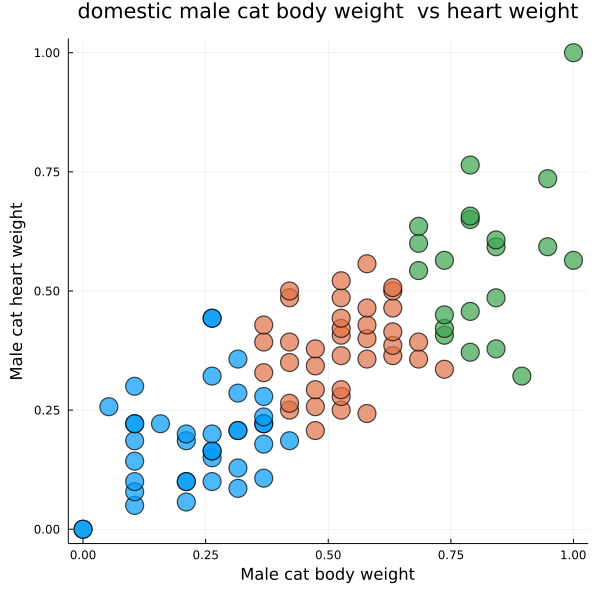

In [17]:
p_kmeans2 = scatter(f1_norm, f2_norm,
        xlabel = "Male cat body weight", 
        ylabel = "Male cat heart weight",
        title = "domestic male cat body weight  vs heart weight",
        legend = false,
        group = a,
        markersize=10,
        alpha =0.7)



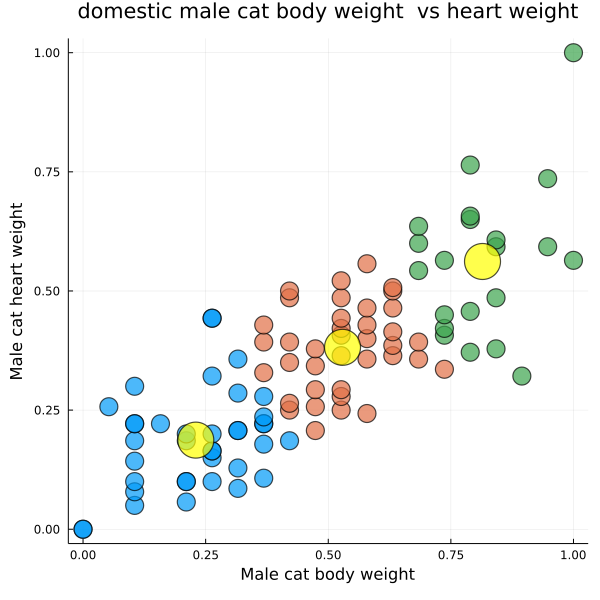

In [18]:
# look at the centroid value
p_center2 = scatter!(μ[1,:], μ[2,:],
        color=:yellow,
        markersize=20,
        alpha =0.7,
        legend = false)


In [19]:
 savefig(p_kmeans,"plotKmeans2.svg")
